# Data Visualization with Matplotlib & Seaborn — Visualization Task
**Name:** Abdlrhman Hisham Ismail
**Id:** AI2617

## Task Overview
This notebook practices **data visualization with Matplotlib and Seaborn** to explore real datasets and communicate insights clearly.

### Datasets
- **Iris**: sepal & petal measurements across 3 species
- **Tips**: restaurant bill & tip data
- **Flights**: monthly passenger counts (1949–1960)

### Deliverables
- **Notebook**: plots for Steps 1–6 + short written insights per dataset
- **Written report (PDF/Word)**: findings + a brief note on **Plotly**, and **Matplotlib vs Seaborn** (differences + when to use each)


## Section 0 — Setup & Data Loading
- Imports + theme
- Load datasets: `iris`, `tips`, `flights`
- Create `flights['date']` (year-month) for time-series plotting


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="darkgrid", palette="dark")

In [3]:
iris = sns.load_dataset('iris')
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')

### Iris — EDA
150 samples, 4 numeric features, 1 categorical (`species`).

In [4]:
print(f"Shape: {iris.shape}")
iris.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### Tips — EDA
244 records of restaurant bills, tips, and customer attributes.

In [8]:
print(f"Shape: {tips.shape}")
tips.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [10]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Flights — EDA
144 monthly passenger counts (1949–1960). We also create a `date` column for time-series plotting.

In [12]:
print(f"Shape: {flights.shape}")
flights.head()

Shape: (144, 3)


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [13]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [14]:
flights.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [15]:
flights.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

In [16]:
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)

In [17]:
flights = flights.sort_values("date").set_index("date")

In [18]:
flights.head()

,year,month,passengers
date,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


In [19]:
flights.index.min(), flights.index.max()

(Timestamp('1949-01-01 00:00:00'), Timestamp('1960-12-01 00:00:00'))

## Step 1 — Line & Scatter Plots
- Iris: `petal_length` vs `petal_width` (colored by species)
- Tips: `total_bill` vs `tip` (colored by time of day)
- Flights: passengers over time (using `date`)


#### Iris scatter — Seaborn
- `petal_length` vs `petal_width`, colored by `species`.


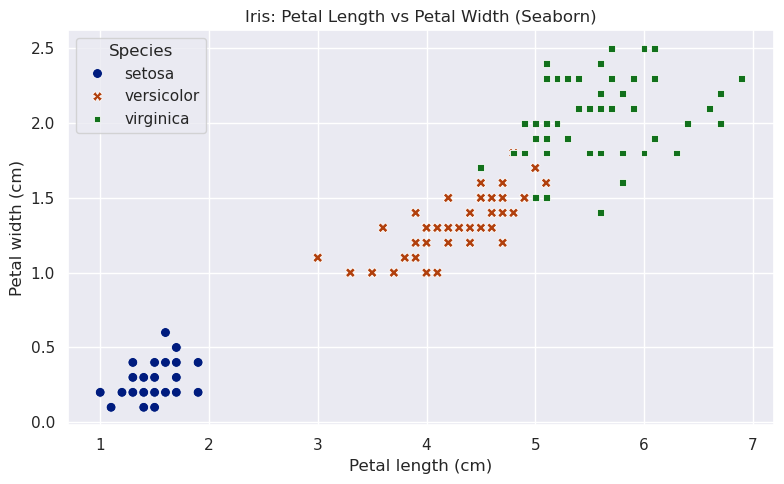

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=iris,
    x="petal_length",
    y="petal_width",
    hue="species",
    style="species",
    s=50
)
plt.title("Iris: Petal Length vs Petal Width (Seaborn)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()



#### Iris scatter — Matplotlib
- Manual color mapping per species + legend.


In [21]:
colors = {"setosa": "red", "versicolor": "blue", "virginica": "green"}

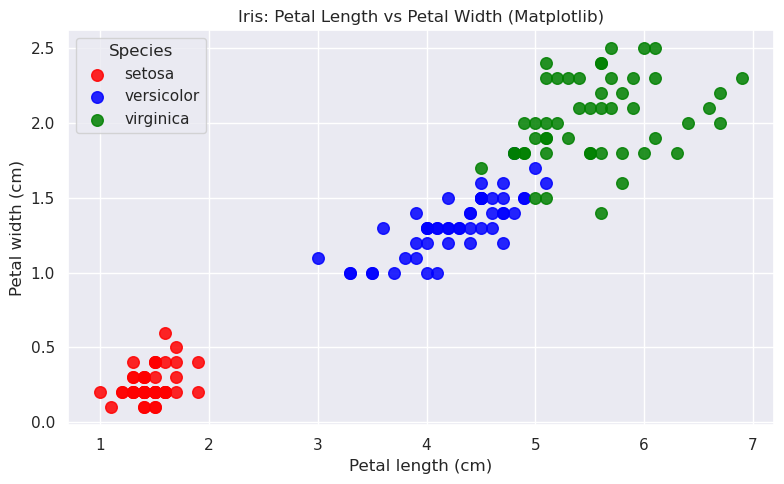

In [22]:
plt.figure(figsize=(8, 5))
for sp, c in colors.items():
    subset = iris[iris["species"] == sp]
    plt.scatter(subset["petal_length"], subset["petal_width"], label=sp, color=c, s=70, alpha=0.85)
plt.title("Iris: Petal Length vs Petal Width (Matplotlib)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

### Tips (scatter)
Scatter of `total_bill` vs `tip`, colored by `time` (Lunch / Dinner) — do bigger bills lead to bigger tips?

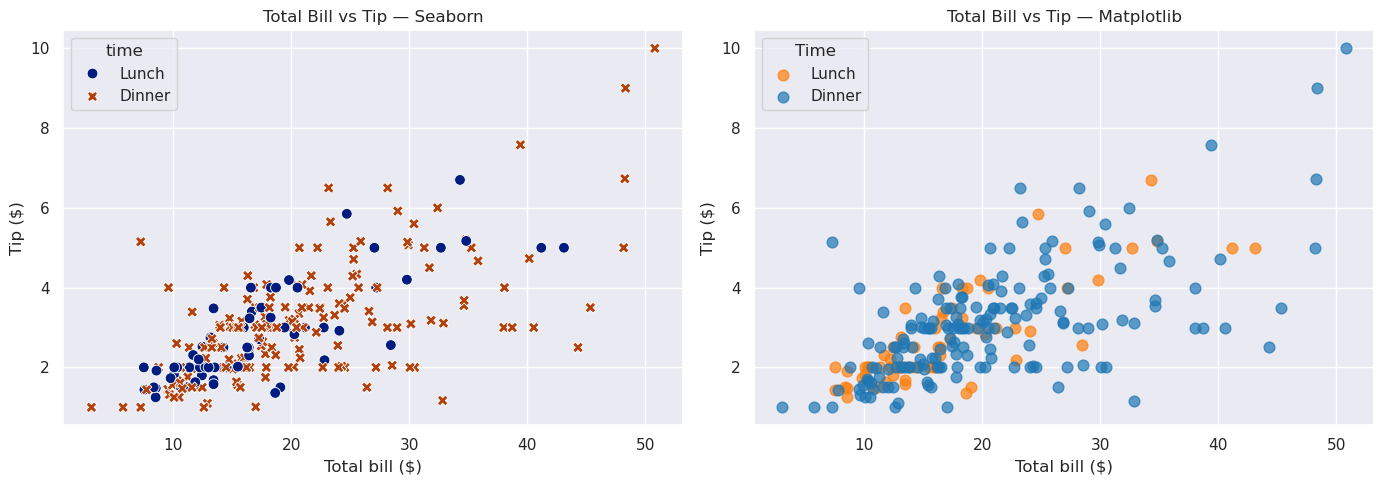

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", style="time", s=60, ax=axes[0])
axes[0].set_title("Total Bill vs Tip — Seaborn")
axes[0].set_xlabel("Total bill ($)")
axes[0].set_ylabel("Tip ($)")

time_colors = {"Lunch": "tab:orange", "Dinner": "tab:blue"}
for t, c in time_colors.items():
    subset = tips[tips["time"] == t]
    axes[1].scatter(subset["total_bill"], subset["tip"], label=t, color=c, s=60, alpha=0.7)
axes[1].set_title("Total Bill vs Tip — Matplotlib")
axes[1].set_xlabel("Total bill ($)")
axes[1].set_ylabel("Tip ($)")
axes[1].legend(title="Time")

fig.tight_layout()
plt.show()

### Flights (time series)
Passengers over time using **Seaborn** `sns.lineplot` and **Matplotlib** `plt.plot`.

#### Flights line plot — Seaborn
- Shows the passenger trend over time (uses the `date` index).


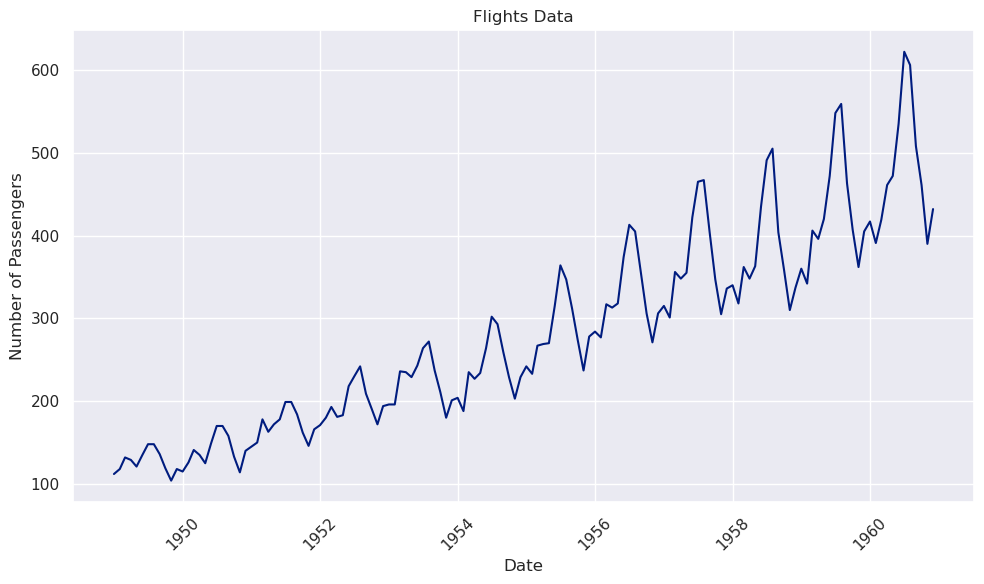

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=flights.index, y=flights["passengers"])
plt.title("Flights Data")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Flights line plot — Matplotlib
- Shows the passenger trend over time (uses the `date` index).


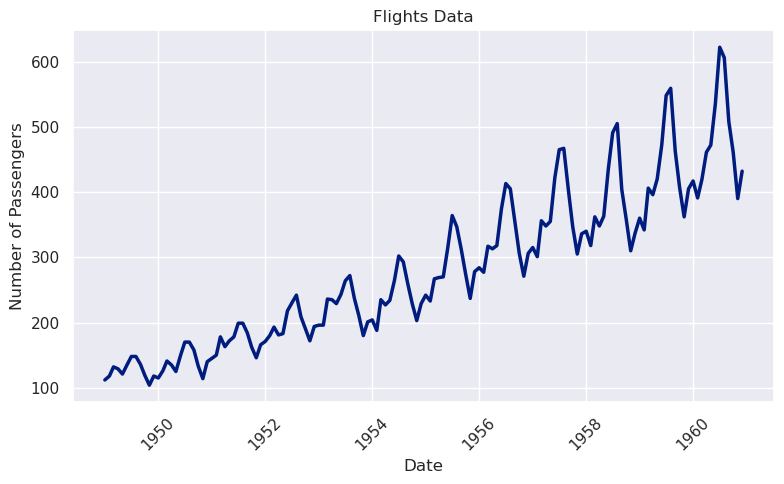

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(flights.index, flights["passengers"], linewidth=2.5)
plt.title("Flights Data")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 2 — Styling & Customization
Demonstrating theme/palette changes, readability controls (fonts, gridlines, tick rotation, axis limits), and before/after comparisons on **multiple datasets**.


In [26]:
x = flights.index
y = flights["passengers"]

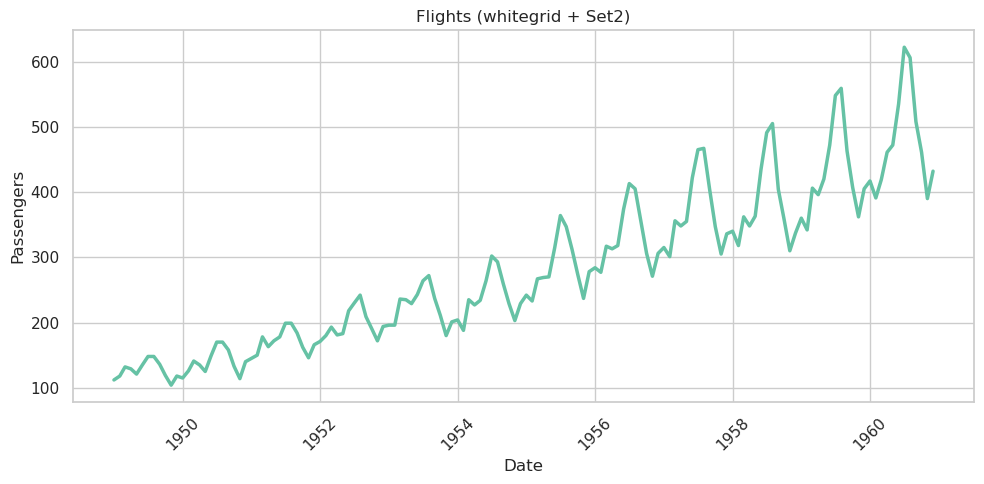

In [27]:
sns.set_theme(style="whitegrid", palette="Set2", context="notebook")

plt.figure(figsize=(10, 5))
sns.lineplot(x=x, y=y, linewidth=2.5)
plt.title("Flights (whitegrid + Set2)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

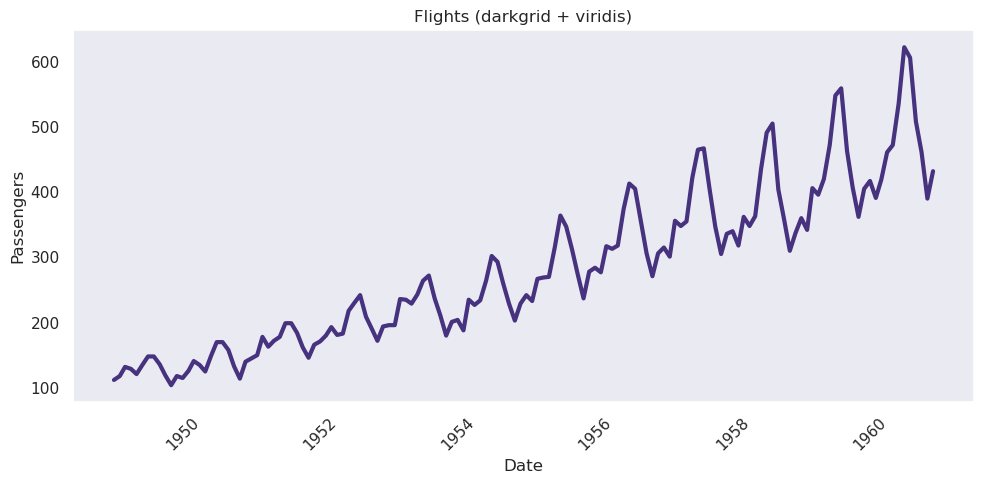

In [28]:
sns.set_theme(style="darkgrid", palette="viridis", context="notebook")
plt.figure(figsize=(10, 5))
sns.lineplot(x=x, y=y, linewidth=3)
plt.title("Flights (darkgrid + viridis)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Before / After — Tips bar plot with different styles
Using `plt.style.context(...)` for **temporary** style changes without polluting the global state.

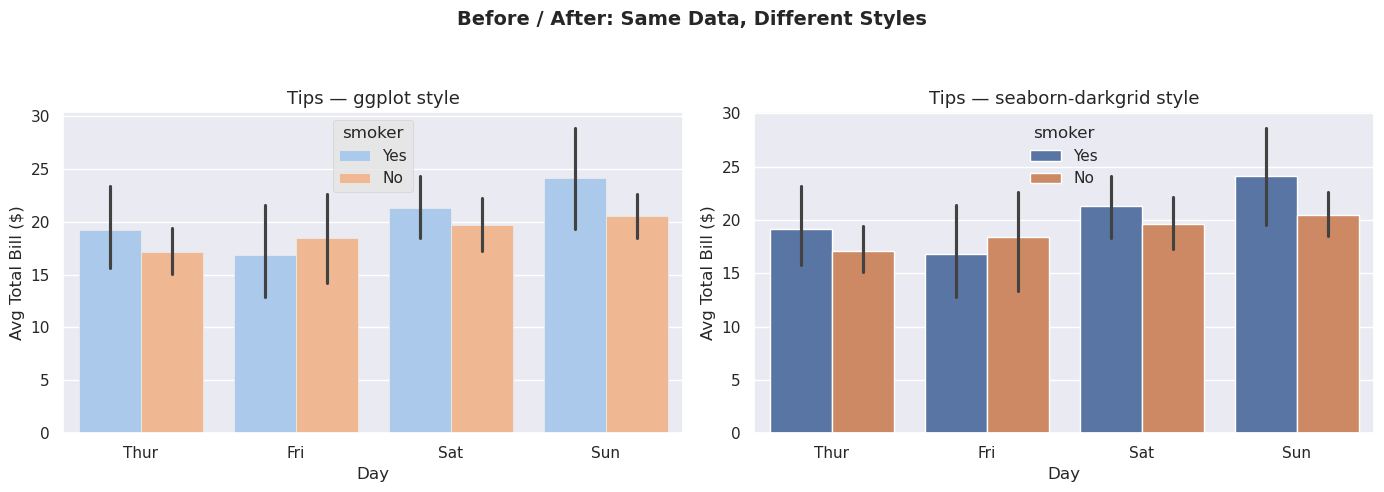

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

with plt.style.context("ggplot"):
    sns.barplot(data=tips, x="day", y="total_bill", ax=axes[0], palette="pastel", hue="smoker")
    axes[0].set_title("Tips — ggplot style", fontsize=13)
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Avg Total Bill ($)")

with plt.style.context("seaborn-v0_8-darkgrid"):
    sns.barplot(data=tips, x="day", y="total_bill", ax=axes[1], palette="deep", hue="smoker")
    axes[1].set_title("Tips — seaborn-darkgrid style", fontsize=13)
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Avg Total Bill ($)")

fig.suptitle("Before / After: Same Data, Different Styles", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [30]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'lines.linewidth': 2.5,
    })

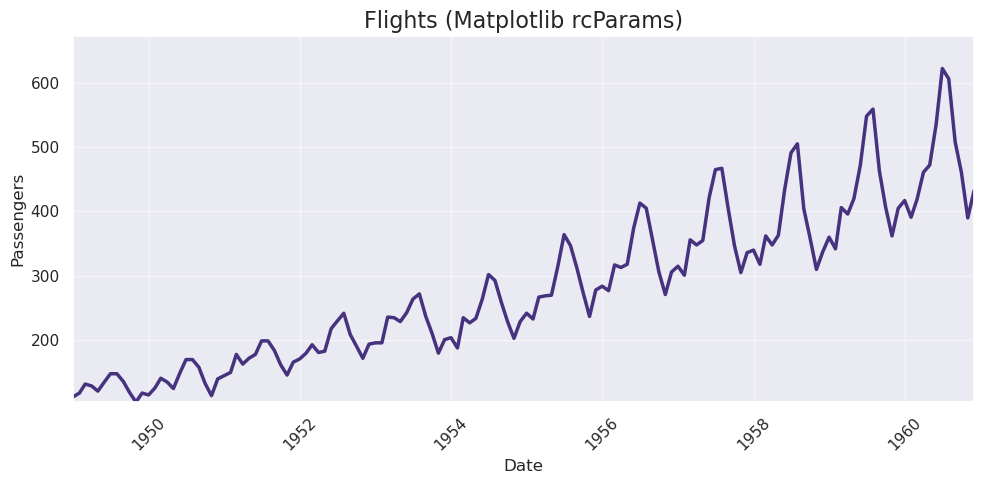

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(flights.index, flights["passengers"])
ax.set_title("Flights (Matplotlib rcParams)")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")

ax.grid(True, alpha=0.5)

ax.set_xlim(flights.index.min(), flights.index.max())
ax.set_ylim(flights["passengers"].min(), flights["passengers"].max() + 50)
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")
plt.rcdefaults()

## Step 3 — Distribution Plots
Distributions for `tips` (and optional iris feature) using histogram+KDE and ECDF.


### 3.1 Histogram + KDE (Tips)
`total_bill` and `tip` distributions.


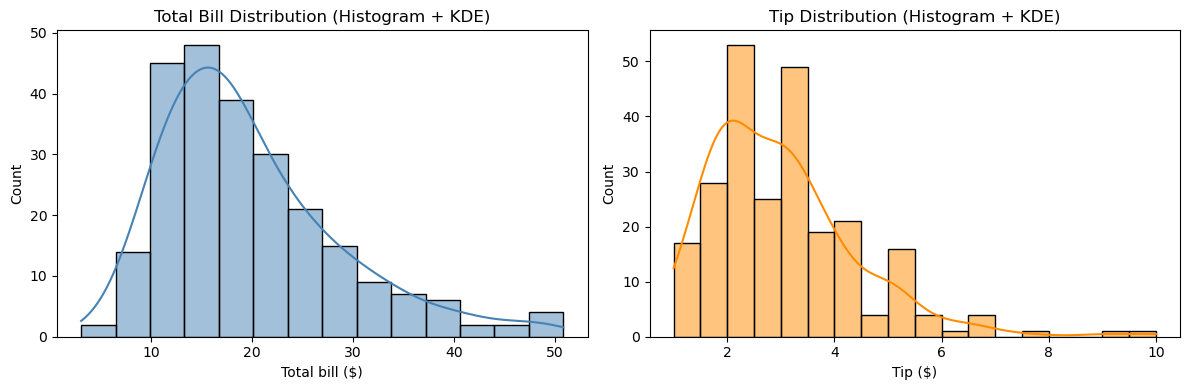

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=tips, x="total_bill", kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Total Bill Distribution (Histogram + KDE)")
axes[0].set_xlabel("Total bill ($)")

sns.histplot(data=tips, x="tip", kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Tip Distribution (Histogram + KDE)")
axes[1].set_xlabel("Tip ($)")
fig.tight_layout()
plt.show()

### 3.2 Group comparison (Tips)
Compare distributions across a category using `hue` (e.g., `time`, `sex`, `smoker`).


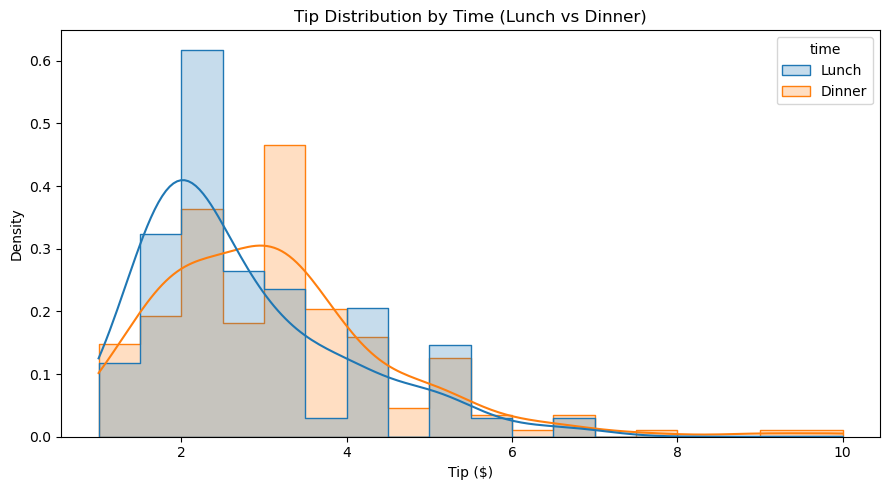

In [33]:
plt.figure(figsize=(9, 5))
sns.histplot(data=tips, x="tip", hue="time", kde=True, element="step", stat="density", common_norm=False)
plt.title("Tip Distribution by Time (Lunch vs Dinner)")
plt.xlabel("Tip ($)")
plt.tight_layout()
plt.show()

### 3.3 ECDF (Tips)
ECDF plot to compare cumulative distributions (e.g., `total_bill` by `smoker`).


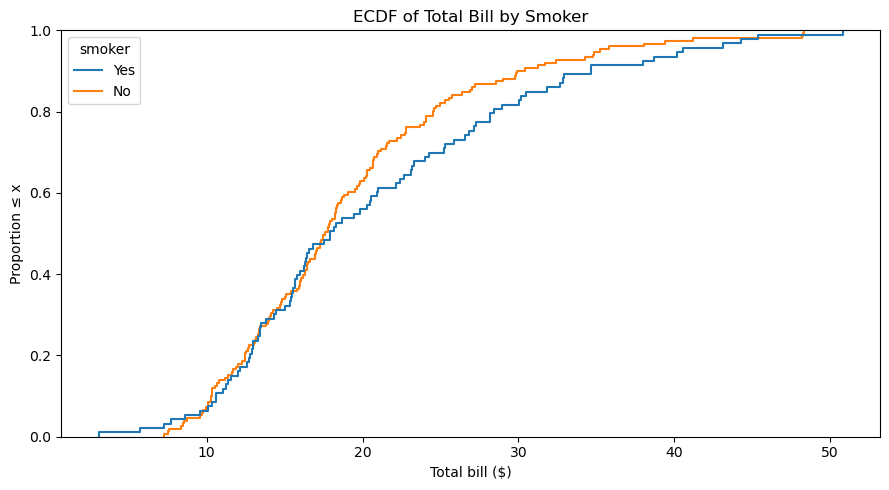

In [34]:
plt.figure(figsize=(9, 5))
sns.ecdfplot(data=tips, x="total_bill", hue="smoker")
plt.title("ECDF of Total Bill by Smoker")
plt.xlabel("Total bill ($)")
plt.ylabel("Proportion ≤ x")
plt.tight_layout()
plt.show()

### 3.4 Optional (Iris)
Distribution of an iris feature (e.g., `sepal_length`) by species.


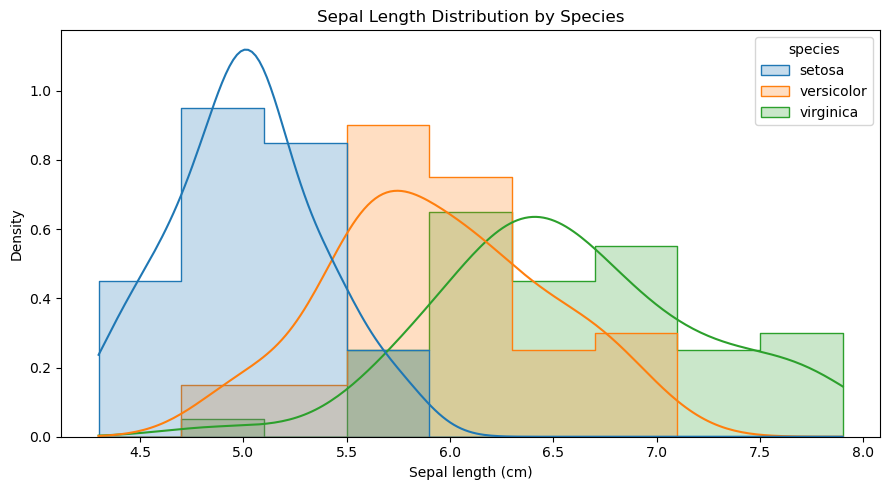

In [35]:
plt.figure(figsize=(9, 5))
sns.histplot(data=iris, x="sepal_length", hue="species", kde=True, element="step", stat="density", common_norm=False)
plt.title("Sepal Length Distribution by Species")
plt.xlabel("Sepal length (cm)")
plt.tight_layout()
plt.show()

### 3.5 Pair Plot (Iris)
All pairwise feature relationships at once, colored by species — a quick way to spot clusters and correlations.

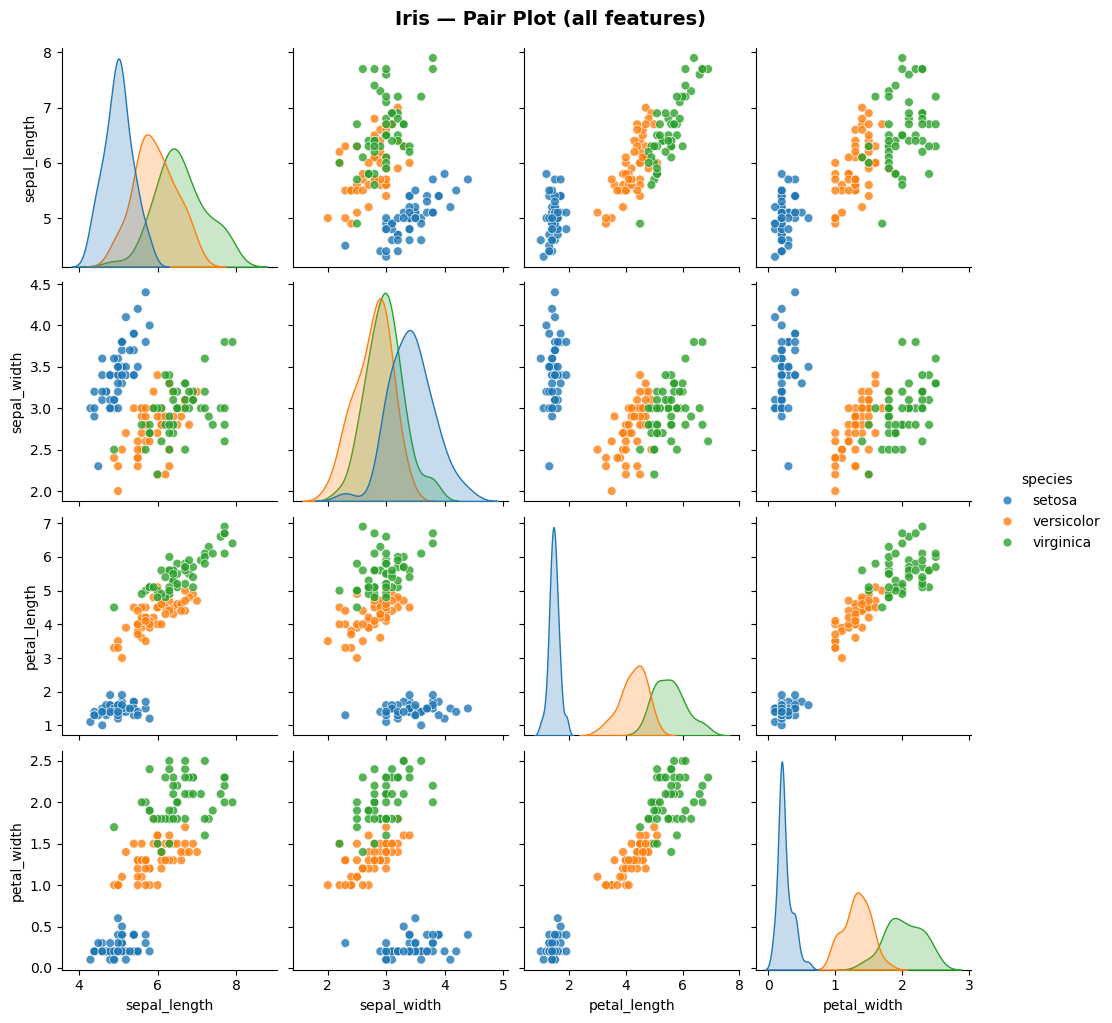

In [36]:
sns.pairplot(iris, hue="species", diag_kind="kde", plot_kws={"alpha": 0.8, "s": 40})
plt.suptitle("Iris — Pair Plot (all features)", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## Step 4 — Categorical & Comparison Plots
Compare groups and highlight differences.

Suggested (Tips dataset):
- Bar plot: average `tip` by `day` or `time` (optional `hue='sex'` or `hue='smoker'`)
- Box plot or violin plot: `tip` distribution by `day` or `time`

Mention which groups have higher typical values and where outliers appear.


### 4.1 Bar Plot — Average Tip by Day
Average `tip` per `day`, split by `smoker` status.

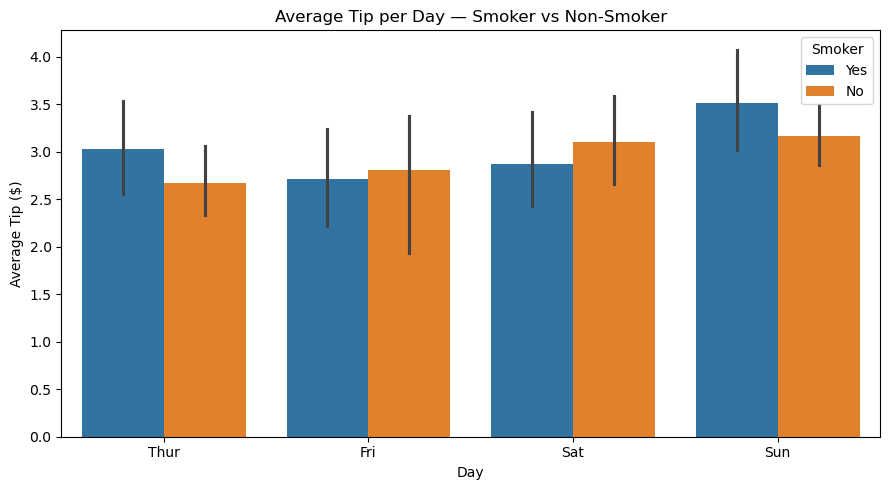

In [37]:
plt.figure(figsize=(9, 5))
sns.barplot(data=tips, x="day", y="tip", hue="smoker")
plt.title("Average Tip per Day — Smoker vs Non-Smoker")
plt.xlabel("Day")
plt.ylabel("Average Tip ($)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()

### 4.2 Box Plot
`tip` distribution by `day`, split by `smoker` — highlights medians, quartiles, and outliers.

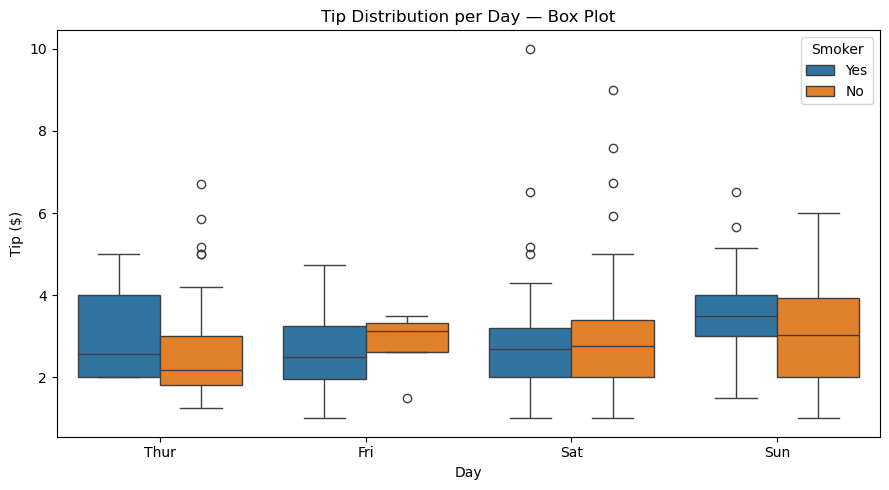

In [38]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=tips, x="day", y="tip", hue="smoker")
plt.title("Tip Distribution per Day — Box Plot")
plt.xlabel("Day")
plt.ylabel("Tip ($)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()

### 4.3 Violin Plot
`tip` distribution by `day`, split by `smoker` — reveals shape and density differences.

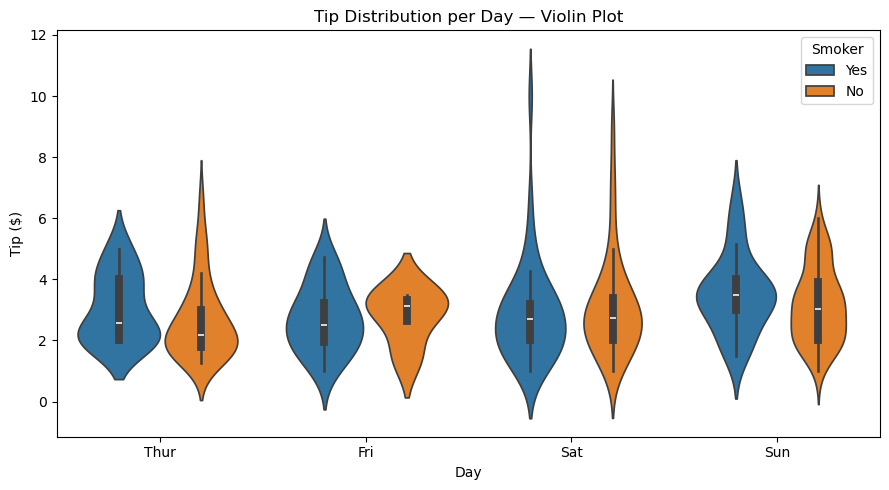

In [39]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=tips, x="day", y="tip", hue="smoker")
plt.title("Tip Distribution per Day — Violin Plot")
plt.xlabel("Day")
plt.ylabel("Tip ($)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()

## Step 5 — Heatmaps & Subplots (OOP API)
Put patterns together and organize multiple plots.

Heatmaps:
- Iris correlation heatmap: `iris.corr(numeric_only=True)` → `sns.heatmap(..., annot=True)`
- Flights pivot heatmap: `flights.reset_index().pivot(index='month', columns='year', values='passengers')`

Subplots (Matplotlib OOP):
- Create a grid with `fig, axes = plt.subplots(2, 2, figsize=(...))`
- Draw 4 plots in the axes and finish with `fig.tight_layout()`


### 5.1 Iris Correlation Heatmap
Pairwise Pearson correlations between all numeric iris features.

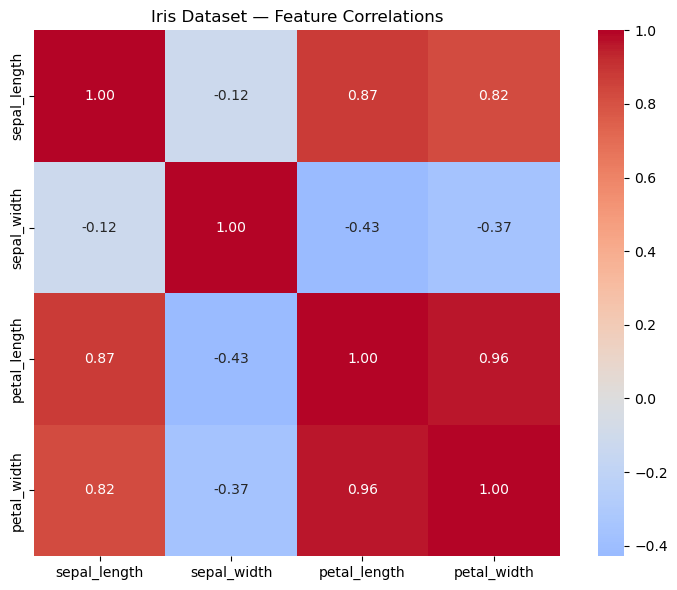

In [40]:
iris_corr = iris.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(iris_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Iris Dataset — Feature Correlations")
plt.tight_layout()
plt.show()

### 5.2 Flights Pivot Heatmap (Month x Year)
Passenger counts arranged as a month-by-year grid.

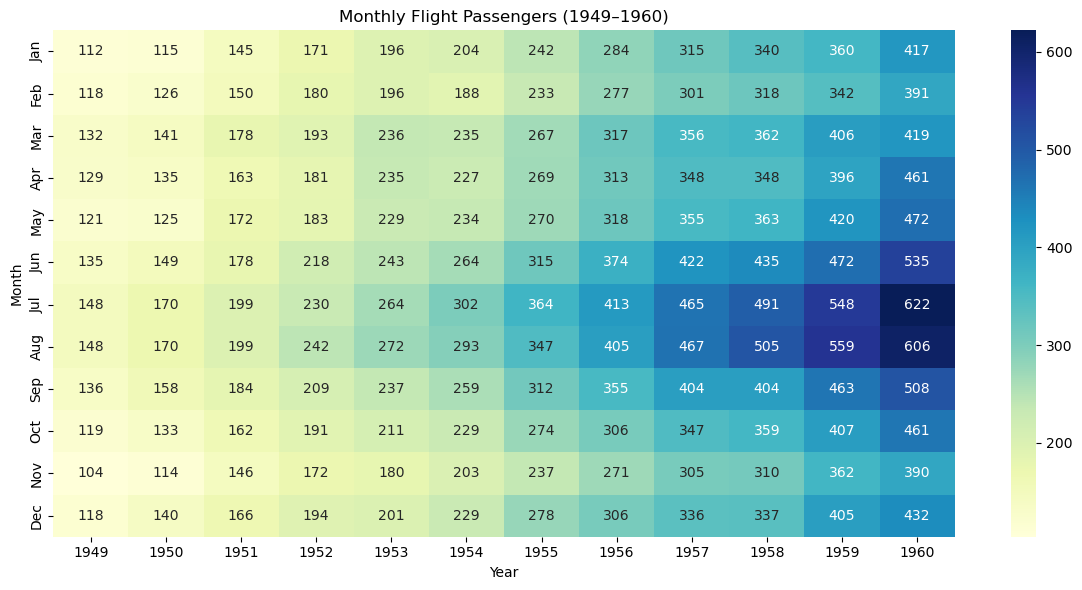

In [41]:
flights_pivot = flights.reset_index().pivot(index="month", columns="year", values="passengers")
plt.figure(figsize=(12, 6))
sns.heatmap(flights_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Monthly Flight Passengers (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

### 5.3 Subplot Grid (2x2) — OOP API
Combine four plots into one dashboard using `fig, axes = plt.subplots()`.

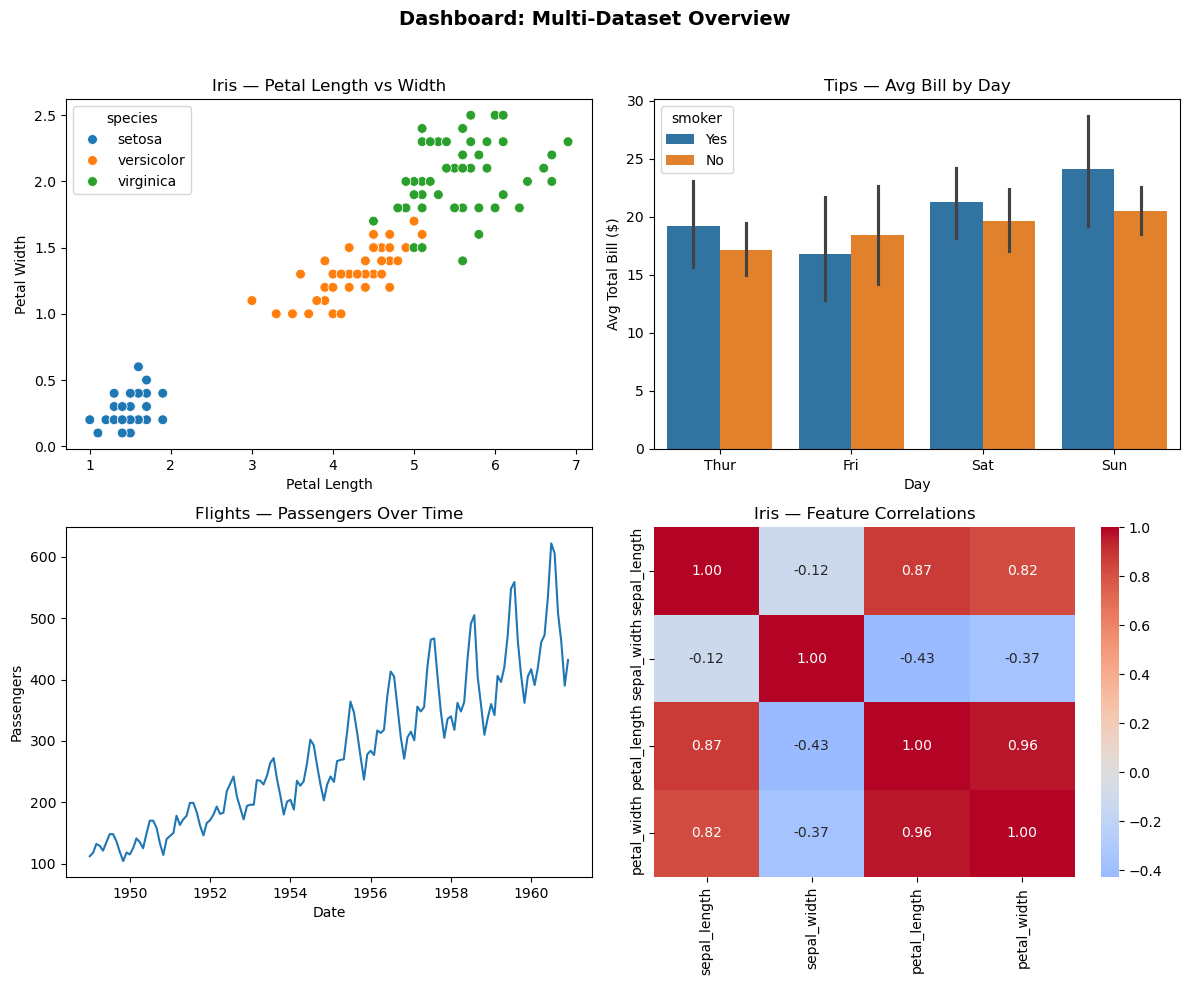

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# [0, 0] Iris scatter
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species", s=50, ax=axes[0, 0])
axes[0, 0].set_title("Iris — Petal Length vs Width")
axes[0, 0].set_xlabel("Petal Length")
axes[0, 0].set_ylabel("Petal Width")

# [0, 1] Tips bar plot
sns.barplot(data=tips, x="day", y="total_bill", hue="smoker", ax=axes[0, 1])
axes[0, 1].set_title("Tips — Avg Bill by Day")
axes[0, 1].set_xlabel("Day")
axes[0, 1].set_ylabel("Avg Total Bill ($)")

# [1, 0] Flights line plot
sns.lineplot(x=flights.index, y=flights["passengers"], ax=axes[1, 0])
axes[1, 0].set_title("Flights — Passengers Over Time")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Passengers")

# [1, 1] Iris correlation heatmap
sns.heatmap(iris_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Iris — Feature Correlations")

fig.suptitle("Dashboard: Multi-Dataset Overview", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Step 6 — Insights & Storytelling
Write **2–3 clear observations per dataset** based directly on the plots above.

### Iris — insights (2–3)
- **Setosa is visually separable** — The scatter plot (petal length vs width) shows setosa clustered in the lower-left with small petals, while versicolor and virginica overlap in the upper-right with larger petals.
- **Petal features are strongly correlated** — The correlation heatmap reveals a high positive correlation between petal length and petal width (~0.96), meaning these two measurements tend to increase together.
- **Species differ in sepal length distribution** — The histogram by species shows setosa has shorter sepals on average, while virginica has the longest; versicolor sits in between.

### Tips — insights (2–3)
- **Saturday has the highest average tips** — The bar and box plots show Saturday consistently has higher typical tip amounts and total bills compared to other days, likely reflecting larger weekend dining parties.
- **Smokers and non-smokers show different tipping patterns** — The bar plot and ECDF reveal that smoker status affects both average tip and total bill distribution; the differences vary by day.
- **Tip distribution is right-skewed with outliers** — The histogram and box plots show most tips cluster at lower values, with a long tail of higher tips and visible outliers on busy days.

### Flights — insights (2–3)
- **Strong upward trend over time** — The line plot shows passenger counts roughly tripling from 1949 to 1960, indicating rapid growth in air travel during this period.
- **Clear seasonal pattern** — The heatmap reveals summer months (June, July, August) consistently have the highest passenger counts each year, while winter months are lighter.
- **Growth is both long-term and seasonal** — Each year’s peak is higher than the previous year’s, so the seasonal pattern repeats on an upward trajectory. 
